# PCA Across Three Sampling Regimes: UCI HAR Full Data vs Two 500-Row `p > n` Subsets

This notebook keeps the same project structure, helper modules, dataset loader, and output folders used elsewhere in the repo, but upgrades the previous high-dimensional comparison into a **three-way PCA study**.

The three scenarios are:
1. the **original full dataset** (`10,299 x 561`, so `n > p`);
2. the **first 500 rows** from the merged HAR table (`500 x 561`, so `p > n`);
3. a **random 500-row sample** from the same merged HAR table (`500 x 561`, so `p > n`, `random_state=42`).

The goal is not only to ask what happens when we move into a strict high-dimensional regime. The notebook also checks whether any differences come from **how the 500 rows were chosen**, especially subject coverage, train/test coverage, row-order effects, and representativeness.

## 1. Why This Revised Notebook Exists

The earlier comparison notebook used only two settings:

- the full dataset;
- the first 500 rows.

That already created a true `p > n` example, but it left an important methodological gap. The first 500 rows are a valid subset, yet they are also an **order-dependent convenience slice**. If that slice contains only a few subjects, then cleaner PCA clusters or higher explained variance might reflect a **narrower sample**, not some general fact about PCA when `p > n`.

This revised notebook adds a second `p > n` scenario: a **random 500-row sample** from the same merged table, using a fixed seed. That gives a stronger check on whether the main PCA story survives when the sample is still small, but is much more representative of the full dataset.

The key question is therefore broader than "Does PCA still work when `p > n`?"

It is:

**Which conclusions are genuinely about dimensionality, and which conclusions depend on sample selection, subject diversity, and representativeness?**

In [39]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.model_selection import train_test_split


def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root from the current working directory."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.data_loader as data_loader
import src.pca_analysis as pca_analysis
import src.preprocessing as preprocessing
import src.utils as utils
import src.visualization as visualization

data_loader = importlib.reload(data_loader)
pca_analysis = importlib.reload(pca_analysis)
preprocessing = importlib.reload(preprocessing)
utils = importlib.reload(utils)
visualization = importlib.reload(visualization)

from src.data_loader import load_har_dataset
from src.pca_analysis import (
    attach_metadata_to_scores,
    build_component_profile,
    build_component_summary,
    build_variance_target_summary,
    fit_full_pca,
    get_top_feature_loadings,
    summarize_activity_centroids,
    summarize_loading_groups,
)
from src.preprocessing import (
    build_dataset_checks_table,
    build_dimension_comparison_table,
    get_class_distribution,
    prepare_pca_input,
)
from src.utils import (
    ensure_project_directories,
    resolve_dataset_dir,
    save_figure,
    save_table,
    set_random_seed,
)
from src.visualization import DEFAULT_ACTIVITY_ORDER, set_plot_style

pd.options.display.max_columns = 40
pd.options.display.max_colwidth = 120

paths = ensure_project_directories(PROJECT_ROOT)
set_random_seed(42)
set_plot_style()

dataset_dir = resolve_dataset_dir(project_root=PROJECT_ROOT)
SCENARIO_COLORS = {
    "Full dataset": "#2563EB",
    "First 500 rows": "#F97316",
    "Random 500 rows": "#14B8A6",
    "Random activity-stratified 500 rows": "#14B8A6",
}
ACTIVITY_PALETTE = dict(
    zip(
        DEFAULT_ACTIVITY_ORDER,
        sns.color_palette("Set2", n_colors=len(DEFAULT_ACTIVITY_ORDER)),
    )
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset directory: {dataset_dir}")

Project root: C:\Users\Nimish\Desktop\human-activity-pca
Dataset directory: C:\Users\Nimish\Desktop\human-activity-pca\data\raw\UCI HAR Dataset


In [40]:
def _need(table: pd.DataFrame, target: str) -> int:
    return int(table.loc[table["target_variance"] == target, "components_needed"].iloc[0])


def build_random_subset(
    dataframe: pd.DataFrame,
    n_rows: int = 500,
    seed: int = 42,
) -> dict[str, object]:
    random_sample = dataframe.sample(n=n_rows, random_state=seed).copy()
    present = set(random_sample["activity_label"])
    missing = [label for label in DEFAULT_ACTIVITY_ORDER if label not in present]

    if missing:
        sampled, _ = train_test_split(
            dataframe,
            train_size=n_rows,
            random_state=seed,
            stratify=dataframe["activity_label"],
        )
        random_sample = sampled.copy()
        short_label = "Random activity-stratified 500 rows"
        title_label = "Random activity-stratified 500 rows (p > n)"
        selection_rule = "Activity-stratified 500-row sample from the merged HAR table"
        sampling_note = (
            f"Pure random sampling with random_state={seed} dropped "
            f"{', '.join(missing)}. The notebook therefore switches to an "
            "activity-stratified sample with the same seed so that all six "
            "classes remain visible."
        )
        sample_method = "Activity-stratified random sample"
    else:
        short_label = "Random 500 rows"
        title_label = "Random 500 rows (p > n)"
        selection_rule = "Pure random 500-row sample from the merged HAR table"
        sampling_note = (
            f"Pure random sample with random_state={seed}; all six activities "
            "remain present, so no stratification is needed."
        )
        sample_method = "Pure random sample"

    return {
        "df": random_sample,
        "short_label": short_label,
        "title_label": title_label,
        "selection_rule": selection_rule,
        "sampling_note": sampling_note,
        "sample_method": sample_method,
        "seed": seed,
    }


def overview_table(scenarios: list[dict[str, object]]) -> pd.DataFrame:
    rows = []
    for scenario in scenarios:
        df = scenario["df"]
        rows.append(
            {
                "scenario": scenario["short_label"],
                "matrix_shape": f"{len(df):,} x {df.shape[1] - 4:,}",
                "dimensionality_regime": scenario["regime"],
                "selection_rule": scenario["selection_rule"],
                "purpose_in_notebook": scenario["purpose"],
                "sampling_note": scenario["sampling_note"],
            }
        )
    return pd.DataFrame(rows)


def setting_table(scenarios: list[dict[str, object]]) -> pd.DataFrame:
    rows = []
    for scenario in scenarios:
        df = scenario["df"]
        n_rows = len(df)
        n_features = df.shape[1] - 4
        subject_share = df["subject_id"].value_counts(normalize=True).sort_values(ascending=False)
        rows.append(
            {
                "scenario": scenario["short_label"],
                "dimensionality_regime": scenario["regime"],
                "rows_n": n_rows,
                "features_p": n_features,
                "p_greater_than_n": "Yes" if n_features > n_rows else "No",
                "feature_to_sample_ratio": round(n_features / n_rows, 3),
                "unique_subjects": int(df["subject_id"].nunique()),
                "dominant_subject_share": float(subject_share.iloc[0]),
                "top_two_subject_share": float(subject_share.head(2).sum()),
                "effective_subject_count": float(1 / subject_share.pow(2).sum()),
                "training_rows": int((df["split"] == "train").sum()),
                "test_rows": int((df["split"] == "test").sum()),
                "activity_classes_present": int(df["activity_label"].nunique()),
                "sklearn_pca_components": min(n_rows, n_features),
                "max_nonzero_pcs_after_centering": min(n_features, n_rows - 1),
                "forced_zero_directions": max(0, n_features - (n_rows - 1)),
            }
        )

    return pd.DataFrame(rows)


def class_count_table(scenarios: list[dict[str, object]]) -> pd.DataFrame:
    out = pd.DataFrame({"activity_label": DEFAULT_ACTIVITY_ORDER})
    for scenario in scenarios:
        count_column = f"{scenario['column_stub']}_count"
        share_column = f"{scenario['column_stub']}_share"
        counts = (
            get_class_distribution(scenario["df"])[["activity_label", "count"]]
            .rename(columns={"count": count_column})
        )
        out = out.merge(counts, on="activity_label", how="left")
        out[count_column] = out[count_column].fillna(0).astype(int)
        out[share_column] = (out[count_column] / len(scenario["df"])).round(4)
    return out


def combined_dataset_checks_table(scenarios: list[dict[str, object]]) -> pd.DataFrame:
    tables = []
    for scenario in scenarios:
        table = build_dataset_checks_table(scenario["df"]).rename(
            columns={"value": scenario["short_label"]}
        )
        tables.append(table)

    merged = tables[0]
    for table in tables[1:]:
        merged = merged.merge(table, on="metric", how="outer")
    return merged


def subject_coverage_table(scenarios: list[dict[str, object]]) -> pd.DataFrame:
    rows = []
    for scenario in scenarios:
        counts = (
            scenario["df"]["subject_id"]
            .value_counts()
            .sort_values(ascending=False)
            .rename_axis("subject_id")
            .reset_index(name="row_count")
        )
        counts["share_of_rows"] = counts["row_count"] / counts["row_count"].sum()
        counts["coverage_rank"] = np.arange(1, len(counts) + 1)
        counts["scenario"] = scenario["short_label"]
        rows.append(counts)
    return pd.concat(rows, ignore_index=True)


def scaling_row(name: str, X_scaled: pd.DataFrame) -> pd.DataFrame:
    feature_means = X_scaled.mean(axis=0)
    feature_stds = X_scaled.std(axis=0, ddof=0)
    return pd.DataFrame(
        {
            "scenario": [name],
            "scaled_matrix_shape": [str(X_scaled.shape)],
            "overall_mean_after_standardization": [float(X_scaled.values.mean())],
            "overall_std_after_standardization": [float(X_scaled.values.std())],
            "largest_abs_feature_mean": [float(feature_means.abs().max())],
            "largest_abs_feature_std_deviation": [float((feature_stds - 1).abs().max())],
        }
    )


def raw_vs_standardized_examples(
    raw_df: pd.DataFrame,
    X_scaled: pd.DataFrame,
    feature_columns: list[str],
    scenario_name: str,
    top_k: int = 5,
) -> pd.DataFrame:
    chosen = feature_columns[:top_k]
    raw = raw_df[chosen]
    scaled = X_scaled[chosen]
    table = pd.DataFrame(
        {
            "scenario": scenario_name,
            "feature_example": chosen,
            "raw_min": raw.min().to_numpy(),
            "raw_max": raw.max().to_numpy(),
            "raw_mean": raw.mean().to_numpy(),
            "raw_std": raw.std(ddof=0).to_numpy(),
            "standardized_min": scaled.min().to_numpy(),
            "standardized_max": scaled.max().to_numpy(),
            "standardized_mean": scaled.mean().to_numpy(),
            "standardized_std": scaled.std(ddof=0).to_numpy(),
        }
    )
    numeric_columns = table.columns.drop(["scenario", "feature_example"])
    table[numeric_columns] = table[numeric_columns].round(4)
    return table

In [41]:
def pca_bundle(df: pd.DataFrame, name: str, top_n: int = 40) -> dict[str, object]:
    X_scaled, feature_columns, scaler = prepare_pca_input(df)
    pca_model, explained_variance, scores_2d = fit_full_pca(X_scaled)
    scores_with_labels = attach_metadata_to_scores(
        scores_2d,
        df[["split", "subject_id", "activity_id", "activity_label"]],
    )
    loading_groups = summarize_loading_groups(
        pca_model,
        feature_columns,
        components=(1, 2),
        top_n=top_n,
    )
    return {
        "dataset_name": name,
        "raw_df": df.copy(),
        "X_scaled": X_scaled,
        "feature_columns": feature_columns,
        "scaler": scaler,
        "pca_model": pca_model,
        "explained_variance": explained_variance,
        "scores_2d": scores_2d,
        "scores_with_labels": scores_with_labels,
        "component_summary": build_component_summary(explained_variance),
        "variance_targets": build_variance_target_summary(
            explained_variance,
            targets=(0.80, 0.90, 0.95),
        ),
        "dimension_comparison": build_dimension_comparison_table(
            X_scaled,
            scores_2d,
            original_label="Original standardized feature space",
            reduced_label="2D PCA space",
        ),
        "loading_groups": loading_groups,
        "component_profile": build_component_profile(loading_groups),
        "top_loadings": get_top_feature_loadings(
            pca_model,
            feature_columns,
            components=(1, 2),
            top_n=10,
        ),
        "activity_centroids": summarize_activity_centroids(scores_with_labels),
    }


def separation_row(result: dict[str, object]) -> pd.DataFrame:
    scores = result["scores_with_labels"].copy()
    centroids = summarize_activity_centroids(scores)
    centroid_matrix = centroids[["mean_pc1", "mean_pc2"]].to_numpy()
    centroid_distances = pairwise_distances(centroid_matrix)
    upper = centroid_distances[np.triu_indices_from(centroid_distances, k=1)]

    spreads = []
    for _, group in scores.groupby("activity_label"):
        centered = group[["PC1", "PC2"]] - group[["PC1", "PC2"]].mean()
        distances = np.sqrt((centered**2).sum(axis=1))
        spreads.append(float(distances.mean()))

    return pd.DataFrame(
        {
            "scenario": [result["dataset_name"]],
            "two_pc_silhouette_score": [
                float(silhouette_score(scores[["PC1", "PC2"]], scores["activity_label"]))
            ],
            "mean_centroid_distance": [float(upper.mean())],
            "min_centroid_distance": [float(upper.min())],
            "max_centroid_distance": [float(upper.max())],
            "avg_within_class_spread": [float(np.mean(spreads))],
        }
    )


def variance_table(results: list[dict[str, object]]) -> pd.DataFrame:
    rows = []
    for result in results:
        ev = result["explained_variance"]
        vt = result["variance_targets"]
        rows.append(
            {
                "scenario": result["dataset_name"],
                "PC1_explained_variance_ratio": float(ev.loc[0, "explained_variance_ratio"]),
                "PC2_explained_variance_ratio": float(ev.loc[1, "explained_variance_ratio"]),
                "first_two_pc_cumulative_variance": float(ev.loc[1, "cumulative_explained_variance"]),
                "PCs_for_80_percent": _need(vt, "80%"),
                "PCs_for_90_percent": _need(vt, "90%"),
                "PCs_for_95_percent": _need(vt, "95%"),
            }
        )
    return pd.DataFrame(rows)


def alignment_table(
    results_by_key: dict[str, dict[str, object]],
    comparison_pairs: list[tuple[str, str]],
    scenario_lookup: dict[str, dict[str, object]],
    top_n: int = 15,
) -> pd.DataFrame:
    rows = []
    for left_key, right_key in comparison_pairs:
        left_result = results_by_key[left_key]
        right_result = results_by_key[right_key]
        left_name = scenario_lookup[left_key]["short_label"]
        right_name = scenario_lookup[right_key]["short_label"]

        for comp in (1, 2):
            left_vector = left_result["pca_model"].components_[comp - 1]
            right_vector = right_result["pca_model"].components_[comp - 1]
            cosine = float(
                np.dot(left_vector, right_vector)
                / (np.linalg.norm(left_vector) * np.linalg.norm(right_vector))
            )
            top_left = set(
                get_top_feature_loadings(
                    left_result["pca_model"],
                    left_result["feature_columns"],
                    components=(comp,),
                    top_n=top_n,
                )["feature_name"]
            )
            top_right = set(
                get_top_feature_loadings(
                    right_result["pca_model"],
                    right_result["feature_columns"],
                    components=(comp,),
                    top_n=top_n,
                )["feature_name"]
            )
            shared = sorted(top_left.intersection(top_right))
            rows.append(
                {
                    "comparison": f"{left_name} vs {right_name}",
                    "component": f"PC{comp}",
                    "loading_cosine_similarity": cosine,
                    "absolute_cosine_similarity": abs(cosine),
                    "shared_top_loading_count": len(shared),
                    "shared_feature_examples": ", ".join(shared[:8]),
                }
            )
    return pd.DataFrame(rows)


def movement_interpretation_row(
    result: dict[str, object],
    short_label: str,
) -> pd.DataFrame:
    centroids = result["activity_centroids"].copy()
    dynamic = {"WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS"}
    stationary = {"SITTING", "STANDING", "LAYING"}
    dynamic_pc1 = centroids.loc[centroids["activity_label"].isin(dynamic), "mean_pc1"].mean()
    stationary_pc1 = centroids.loc[centroids["activity_label"].isin(stationary), "mean_pc1"].mean()
    upstairs_pc2 = float(
        centroids.loc[centroids["activity_label"] == "WALKING_UPSTAIRS", "mean_pc2"].iloc[0]
    )
    other_walk_pc2 = centroids.loc[
        centroids["activity_label"].isin(["WALKING", "WALKING_DOWNSTAIRS"]),
        "mean_pc2",
    ].mean()
    return pd.DataFrame(
        {
            "scenario": [short_label],
            "dynamic_mean_pc1": [dynamic_pc1],
            "stationary_mean_pc1": [stationary_pc1],
            "walking_upstairs_mean_pc2": [upstairs_pc2],
            "other_walking_mean_pc2": [other_walk_pc2],
        }
    )

## 2. Define the Three Dataset Scenarios

The dataset is the same **UCI Human Activity Recognition Using Smartphones** dataset used in the original notebook.

- 30 volunteers performed 6 activities while wearing a smartphone on the waist.
- Each row is a 2.56-second sliding window of motion data.
- Each row has 561 engineered time-domain and frequency-domain features.

The revised comparison uses three versions of the same merged HAR table:

1. **Full dataset**: the baseline `n > p` setting.
2. **First 500 rows**: an intentionally order-dependent `p > n` slice.
3. **Random 500 rows**: a reproducible `p > n` subset chosen with `random_state=42`.

The first 500 rows are still useful because they create a strict high-dimensional example with minimal extra logic. The random 500-row sample exists because the first 500 rows may be methodologically narrow if the merged table starts with only a small set of subjects.

In [42]:
har_df = load_har_dataset(dataset_dir)
random_subset_info = build_random_subset(har_df, n_rows=500, seed=42)

scenarios = [
    {
        "key": "full",
        "column_stub": "full_dataset",
        "short_label": "Full dataset",
        "title_label": "Full dataset (n > p)",
        "regime": "n > p",
        "selection_rule": "All rows from the merged train + test HAR table",
        "sampling_note": "Baseline reference using the original merged dataset.",
        "purpose": "Reference setting with many more rows than features.",
        "df": har_df,
    },
    {
        "key": "first_500",
        "column_stub": "first_500_rows",
        "short_label": "First 500 rows",
        "title_label": "First 500 rows (p > n)",
        "regime": "p > n",
        "selection_rule": "Use the first 500 rows from the merged HAR table",
        "sampling_note": "Convenience slice: valid for teaching `p > n`, but fully dependent on row order.",
        "purpose": "Order-based high-dimensional subset with minimal extra sampling logic.",
        "df": har_df.head(500).copy(),
    },
    {
        "key": "random_500",
        "column_stub": "random_500_rows",
        "short_label": random_subset_info["short_label"],
        "title_label": random_subset_info["title_label"],
        "regime": "p > n",
        "selection_rule": random_subset_info["selection_rule"],
        "sampling_note": random_subset_info["sampling_note"],
        "purpose": "Broader high-dimensional subset that checks whether the `p > n` story survives under better coverage.",
        "df": random_subset_info["df"],
    },
]

scenario_lookup = {scenario["key"]: scenario for scenario in scenarios}
scenario_results_order = [scenario["key"] for scenario in scenarios]

scenario_overview = overview_table(scenarios)
setting_comparison = setting_table(scenarios)

save_table(scenario_overview, paths["tables"] / "three_way_overview.csv")
save_table(setting_comparison, paths["tables"] / "three_way_setting_comparison.csv")

setting_display = setting_comparison.copy()
for column in ["dominant_subject_share", "top_two_subject_share"]:
    setting_display[column] = (setting_display[column] * 100).round(1).astype(str) + "%"
setting_display["effective_subject_count"] = setting_display["effective_subject_count"].round(2)

display(scenario_overview)
display(setting_display)
display(Markdown(f"**Random-sample note.** {random_subset_info['sampling_note']}"))

,scenario,matrix_shape,dimensionality_regime,selection_rule,purpose_in_notebook,sampling_note
0,Full dataset,"10,299 x 561",n > p,All rows from the merged train + test HAR table,Reference setting with many more rows than features.,Baseline reference using the original merged dataset.
1,First 500 rows,500 x 561,p > n,Use the first 500 rows from the merged HAR table,Order-based high-dimensional subset with minimal extra sampling logic.,"Convenience slice: valid for teaching `p > n`, but fully dependent on row order."
2,Random 500 rows,500 x 561,p > n,Pure random 500-row sample from the merged HAR table,Broader high-dimensional subset that checks whether the `p > n` story survives under better coverage.,"Pure random sample with random_state=42; all six activities remain present, so no stratification is needed."


,scenario,dimensionality_regime,rows_n,features_p,p_greater_than_n,feature_to_sample_ratio,unique_subjects,dominant_subject_share,top_two_subject_share,effective_subject_count,training_rows,test_rows,activity_classes_present,sklearn_pca_components,max_nonzero_pcs_after_centering,forced_zero_directions
0,Full dataset,n > p,10299,561,No,0.054,30,4.0%,7.9%,29.69,7352,2947,6,561,561,0
1,First 500 rows,p > n,500,561,Yes,1.122,2,69.4%,100.0%,1.74,500,0,6,500,499,62
2,Random 500 rows,p > n,500,561,Yes,1.122,30,5.8%,11.0%,28.17,352,148,6,500,499,62


**Random-sample note.** Pure random sample with random_state=42; all six activities remain present, so no stratification is needed.

## 3. Dataset Checks and Representativeness Checks

This section is central to the revised notebook.

Both 500-row settings are high-dimensional because `p > n`, but they are **not equally representative**:

- the first 500 rows are a valid teaching example, yet they depend entirely on row order;
- the random 500-row sample is still small, but it should usually reflect the full subject pool much better.

That means we should not attribute every PCA difference only to `p > n`. Some differences may come from **subject concentration**, **train/test coverage**, and **who happens to appear in the subset**.

,metric,Full dataset,First 500 rows,Random 500 rows
0,Activity classes,6,6,6
1,Feature columns,561,561,561
2,Missing values in features,0,0,0
3,Rows (activity windows),10299,500,500
4,Test rows,2947,0,148
5,Training rows,7352,500,352
6,Unique subjects,30,2,30


,activity_label,full_dataset_count,full_dataset_share,first_500_rows_count,first_500_rows_share,random_500_rows_count,random_500_rows_share
0,WALKING,1722,16.7%,126,25.2%,99,19.8%
1,WALKING_UPSTAIRS,1544,15.0%,65,13.0%,69,13.8%
2,WALKING_DOWNSTAIRS,1406,13.6%,72,14.4%,61,12.2%
3,SITTING,1777,17.2%,73,14.6%,98,19.6%
4,STANDING,1906,18.5%,84,16.8%,69,13.8%
5,LAYING,1944,18.9%,80,16.0%,104,20.8%


,scenario,unique_subjects,dominant_subject_share,top_two_subject_share,effective_subject_count,training_rows,test_rows,activity_classes_present
0,Full dataset,30,4.0%,7.9%,29.69,7352,2947,6
1,First 500 rows,2,69.4%,100.0%,1.74,500,0,6
2,Random 500 rows,30,5.8%,11.0%,28.17,352,148,6


### Top subject coverage inside the two `p > n` subsets

,subject_id,row_count,share_of_rows,coverage_rank,scenario
30,1,347,69.4%,1,First 500 rows
31,3,153,30.6%,2,First 500 rows
32,17,29,5.8%,1,Random 500 rows
33,19,26,5.2%,2,Random 500 rows
34,1,23,4.6%,3,Random 500 rows
35,4,21,4.2%,4,Random 500 rows
36,27,21,4.2%,5,Random 500 rows
37,9,19,3.8%,6,Random 500 rows
38,6,19,3.8%,7,Random 500 rows
39,25,19,3.8%,8,Random 500 rows


The **first 500 rows** scenario is a valid `p > n` example, but it is also methodologically narrow. In this dataset it covers only **2 subjects**, all **500 rows** come from the training split, and the largest single subject contributes **69.4%** of the sample. In fact, the top two subjects account for **100.0%** of the rows. By contrast, the **Random 500 rows** scenario covers **30 subjects**, includes **148 test rows**, and its largest subject contributes only **5.8%** of the sample. That is why differences between the two 500-row PCA fits should not be attributed to `p > n` alone.

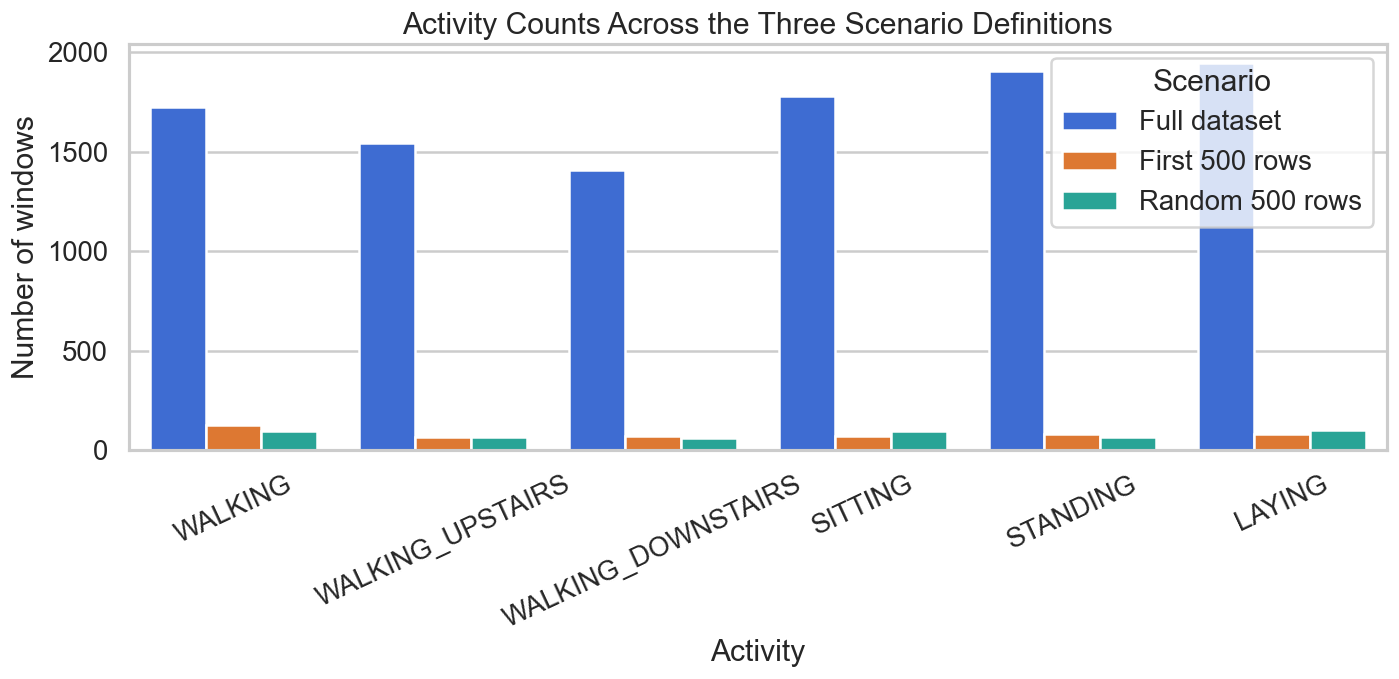

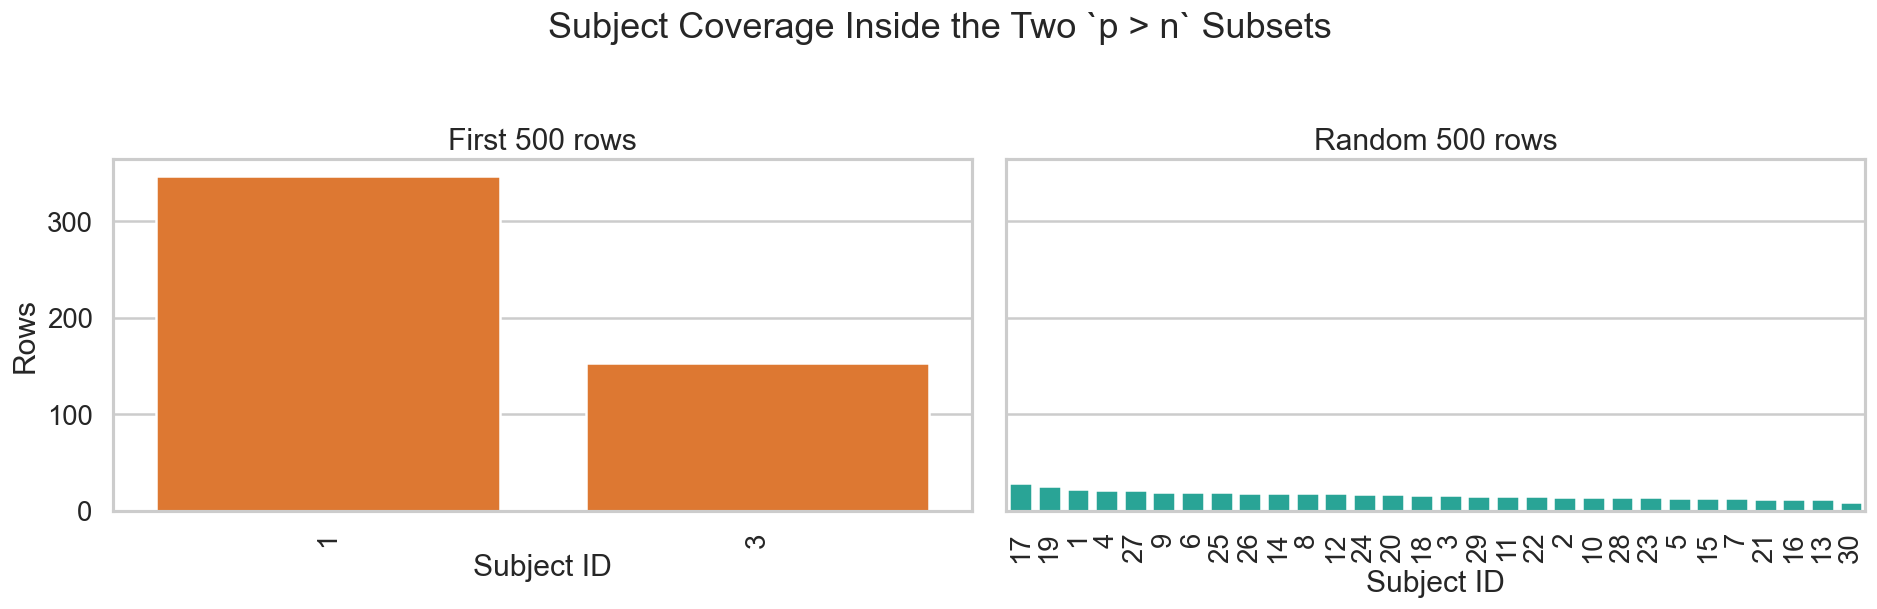

In [43]:
dataset_checks = combined_dataset_checks_table(scenarios)
class_counts = class_count_table(scenarios)
subject_coverage = subject_coverage_table(scenarios)
subject_concentration = setting_comparison[
    [
        "scenario",
        "unique_subjects",
        "dominant_subject_share",
        "top_two_subject_share",
        "effective_subject_count",
        "training_rows",
        "test_rows",
        "activity_classes_present",
    ]
].copy()

save_table(dataset_checks, paths["tables"] / "three_way_dataset_checks.csv")
save_table(class_counts, paths["tables"] / "three_way_class_count_comparison.csv")
save_table(subject_coverage, paths["tables"] / "three_way_subject_coverage.csv")
save_table(subject_concentration, paths["tables"] / "three_way_subject_concentration.csv")

display(dataset_checks.copy())

class_counts_display = class_counts.copy()
for column in class_counts_display.columns:
    if column.endswith("_share"):
        class_counts_display[column] = (class_counts_display[column] * 100).round(1).astype(str) + "%"
display(class_counts_display)

subject_concentration_display = subject_concentration.copy()
for column in ["dominant_subject_share", "top_two_subject_share"]:
    subject_concentration_display[column] = (
        subject_concentration_display[column] * 100
    ).round(1).astype(str) + "%"
subject_concentration_display["effective_subject_count"] = (
    subject_concentration_display["effective_subject_count"].round(2)
)
display(subject_concentration_display)

top_subjects_display = subject_coverage[
    (subject_coverage["scenario"] != "Full dataset")
    & (subject_coverage["coverage_rank"] <= 10)
].copy()
top_subjects_display["share_of_rows"] = (
    top_subjects_display["share_of_rows"] * 100
).round(1).astype(str) + "%"
display(Markdown("### Top subject coverage inside the two `p > n` subsets"))
display(top_subjects_display)

first_subjects = int(
    setting_comparison.loc[
        setting_comparison["scenario"] == "First 500 rows", "unique_subjects"
    ].iloc[0]
)
random_subjects = int(
    setting_comparison.loc[
        setting_comparison["scenario"] == random_subset_info["short_label"], "unique_subjects"
    ].iloc[0]
)
first_dominant = float(
    setting_comparison.loc[
        setting_comparison["scenario"] == "First 500 rows", "dominant_subject_share"
    ].iloc[0]
)
random_dominant = float(
    setting_comparison.loc[
        setting_comparison["scenario"] == random_subset_info["short_label"], "dominant_subject_share"
    ].iloc[0]
)
first_top_two = float(
    setting_comparison.loc[
        setting_comparison["scenario"] == "First 500 rows", "top_two_subject_share"
    ].iloc[0]
)
random_top_two = float(
    setting_comparison.loc[
        setting_comparison["scenario"] == random_subset_info["short_label"], "top_two_subject_share"
    ].iloc[0]
)
first_train = int(
    setting_comparison.loc[
        setting_comparison["scenario"] == "First 500 rows", "training_rows"
    ].iloc[0]
)
random_test = int(
    setting_comparison.loc[
        setting_comparison["scenario"] == random_subset_info["short_label"], "test_rows"
    ].iloc[0]
)

display(
    Markdown(
        f"The **first 500 rows** scenario is a valid `p > n` example, but it is also methodologically narrow. "
        f"In this dataset it covers only **{first_subjects} subjects**, all **{first_train} rows** come from the training split, and the largest single subject contributes **{first_dominant:.1%}** of the sample. "
        f"In fact, the top two subjects account for **{first_top_two:.1%}** of the rows. By contrast, the **{random_subset_info['short_label']}** scenario covers **{random_subjects} subjects**, includes **{random_test} test rows**, and its largest subject contributes only **{random_dominant:.1%}** of the sample. "
        "That is why differences between the two 500-row PCA fits should not be attributed to `p > n` alone."
    )
)

class_plot = class_counts.melt(
    id_vars="activity_label",
    value_vars=[
        "full_dataset_count",
        "first_500_rows_count",
        "random_500_rows_count",
    ],
    var_name="scenario_key",
    value_name="count",
)
class_plot["scenario"] = class_plot["scenario_key"].map(
    {
        "full_dataset_count": "Full dataset",
        "first_500_rows_count": "First 500 rows",
        "random_500_rows_count": random_subset_info["short_label"],
    }
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=class_plot,
    x="activity_label",
    y="count",
    hue="scenario",
    order=DEFAULT_ACTIVITY_ORDER,
    hue_order=["Full dataset", "First 500 rows", random_subset_info["short_label"]],
    palette=[
        SCENARIO_COLORS["Full dataset"],
        SCENARIO_COLORS["First 500 rows"],
        SCENARIO_COLORS[random_subset_info["short_label"]],
    ],
    ax=ax,
)
ax.set_title("Activity Counts Across the Three Scenario Definitions")
ax.set_xlabel("Activity")
ax.set_ylabel("Number of windows")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Scenario")
fig.tight_layout()
save_figure(fig, paths["figures"] / "three_way_class_count_comparison.png")
plt.show()
plt.close(fig)

subject_plot = subject_coverage[
    subject_coverage["scenario"].isin(["First 500 rows", random_subset_info["short_label"]])
].copy()
subject_plot["subject_id"] = subject_plot["subject_id"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for axis, scenario_name in zip(axes, ["First 500 rows", random_subset_info["short_label"]]):
    plot_data = subject_plot[subject_plot["scenario"] == scenario_name].copy()
    plot_data["subject_id"] = pd.Categorical(
        plot_data["subject_id"],
        categories=plot_data["subject_id"].tolist(),
        ordered=True,
    )
    sns.barplot(
        data=plot_data,
        x="subject_id",
        y="row_count",
        color=SCENARIO_COLORS[scenario_name],
        ax=axis,
    )
    axis.set_title(scenario_name)
    axis.set_xlabel("Subject ID")
    axis.set_ylabel("Rows")
    axis.tick_params(axis="x", rotation=90)

fig.suptitle("Subject Coverage Inside the Two `p > n` Subsets", y=1.03)
fig.tight_layout()
save_figure(fig, paths["figures"] / "three_way_subject_coverage.png")
plt.show()
plt.close(fig)

## 4. Preprocessing / Standardization

The preprocessing logic stays the same as in the original notebook and the earlier generated comparison.

PCA is still sensitive to scale, so each feature is standardized separately before fitting the decomposition. For feature `j`, the transformed value for observation `i` is

$$
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$

where `\mu_j` and `\sigma_j` are computed **feature by feature** inside the selected scenario.

This point matters just as much in the two `p > n` subsets as it does in the full dataset. Without feature-wise standardization, a few high-magnitude variables could dominate the principal components for purely numeric reasons.

In [44]:
prepared_inputs = {}
scaling_checks = []
raw_vs_standardized = []

for scenario in scenarios:
    X_scaled, feature_columns, scaler = prepare_pca_input(scenario["df"])
    prepared_inputs[scenario["key"]] = {
        "X_scaled": X_scaled,
        "feature_columns": feature_columns,
        "scaler": scaler,
    }
    scaling_checks.append(scaling_row(scenario["short_label"], X_scaled))
    raw_vs_standardized.append(
        raw_vs_standardized_examples(
            scenario["df"],
            X_scaled,
            feature_columns,
            scenario["short_label"],
            top_k=5,
        )
    )

scaling_checks = pd.concat(scaling_checks, ignore_index=True)
raw_vs_standardized = pd.concat(raw_vs_standardized, ignore_index=True)

numeric_scaling_cols = scaling_checks.columns.drop(["scenario", "scaled_matrix_shape"])
scaling_checks[numeric_scaling_cols] = scaling_checks[numeric_scaling_cols].round(6)

save_table(scaling_checks, paths["tables"] / "three_way_scaling_checks.csv")
save_table(raw_vs_standardized, paths["tables"] / "three_way_raw_vs_standardized_examples.csv")

display(scaling_checks)
display(
    Markdown(
        "### Raw vs standardized examples\n"
        "The same first five HAR features are shown for each scenario. After standardization, the feature means are near 0 and the feature standard deviations are near 1 in every case."
    )
)
display(raw_vs_standardized)

,scenario,scaled_matrix_shape,overall_mean_after_standardization,overall_std_after_standardization,largest_abs_feature_mean,largest_abs_feature_std_deviation
0,Full dataset,"(10299, 561)",0.0,1.0,0.0,0.0
1,First 500 rows,"(500, 561)",0.0,1.0,0.0,0.0
2,Random 500 rows,"(500, 561)",-0.0,1.0,0.0,0.0


### Raw vs standardized examples
The same first five HAR features are shown for each scenario. After standardization, the feature means are near 0 and the feature standard deviations are near 1 in every case.

,scenario,feature_example,raw_min,raw_max,raw_mean,raw_std,standardized_min,standardized_max,standardized_mean,standardized_std
0,Full dataset,tBodyAcc-mean()-X,-1.0000,1.0000,0.2743,0.0676,-18.8445,10.7306,-0.0,1.0
1,Full dataset,tBodyAcc-mean()-Y,-1.0000,1.0000,-0.0177,0.0371,-26.4571,27.4130,0.0,1.0
2,Full dataset,tBodyAcc-mean()-Z,-1.0000,1.0000,-0.1089,0.0530,-16.8031,20.9111,0.0,1.0
3,Full dataset,tBodyAcc-std()-X,-1.0000,1.0000,-0.6078,0.4387,-0.8941,3.6651,-0.0,1.0
4,Full dataset,tBodyAcc-std()-Y,-1.0000,1.0000,-0.5102,0.5002,-0.9792,3.0191,0.0,1.0
5,First 500 rows,tBodyAcc-mean()-X,-0.3612,0.4699,0.2675,0.0794,-7.9158,2.5492,0.0,1.0
6,First 500 rows,tBodyAcc-mean()-Y,-0.6841,0.3241,-0.0168,0.0489,-13.6453,6.9727,0.0,1.0
7,First 500 rows,tBodyAcc-mean()-Z,-1.0000,0.3467,-0.1063,0.0686,-13.0305,6.6039,0.0,1.0
8,First 500 rows,tBodyAcc-std()-X,-0.9993,0.3891,-0.5814,0.3945,-1.0594,2.4604,0.0,1.0
9,First 500 rows,tBodyAcc-std()-Y,-0.9984,0.5325,-0.4167,0.4961,-1.1725,1.9136,0.0,1.0


## 5. PCA Setup and the Dimensionality Constraint

PCA rotates the standardized data into new orthogonal axes that capture the strongest remaining variance.

- **PC1** captures the largest single variance direction.
- **PC2** captures the next strongest direction, subject to being orthogonal to PC1.
- The **explained variance ratio** tells us how much variance each component keeps.
- The **cumulative explained variance** shows how quickly the retained variance adds up.

The important change in the two 500-row scenarios is not just that they are smaller. It is that they satisfy **`p > n`**.

With `n = 500` rows and `p = 561` features:

- scikit-learn can report at most `min(n, p) = 500` components;
- after centering, the data matrix has rank at most `n - 1 = 499`;
- therefore at least `561 - 499 = 62` directions must have zero sample variance.

That dimensionality cap applies to **both** 500-row scenarios. The notebook now asks whether the resulting PCA summaries are still similar once we vary representativeness.

In [45]:
top_loading_window = 40
results = {}
for scenario in scenarios:
    result = pca_bundle(scenario["df"], scenario["title_label"], top_n=top_loading_window)
    result["key"] = scenario["key"]
    result["short_label"] = scenario["short_label"]
    results[scenario["key"]] = result

variance_comparison = variance_table([results[key] for key in scenario_results_order])
separation_comparison = pd.concat(
    [separation_row(results[key]) for key in scenario_results_order],
    ignore_index=True,
)
component_alignment = alignment_table(
    results,
    [("full", "first_500"), ("full", "random_500"), ("first_500", "random_500")],
    scenario_lookup,
    top_n=15,
)
dimension_comparison = pd.concat(
    [
        results[key]["dimension_comparison"].assign(scenario=scenario_lookup[key]["title_label"])
        for key in scenario_results_order
    ],
    ignore_index=True,
)
activity_centroids = pd.concat(
    [
        results[key]["activity_centroids"].assign(scenario=scenario_lookup[key]["short_label"])
        for key in scenario_results_order
    ],
    ignore_index=True,
)
component_profiles = pd.concat(
    [
        results[key]["component_profile"].assign(scenario=scenario_lookup[key]["short_label"])
        for key in scenario_results_order
    ],
    ignore_index=True,
)
top_loadings = pd.concat(
    [
        results[key]["top_loadings"].assign(scenario=scenario_lookup[key]["short_label"])
        for key in scenario_results_order
    ],
    ignore_index=True,
)
movement_summary = pd.concat(
    [
        movement_interpretation_row(results[key], scenario_lookup[key]["short_label"])
        for key in scenario_results_order
    ],
    ignore_index=True,
)

save_table(variance_comparison, paths["tables"] / "three_way_variance_comparison.csv")
save_table(separation_comparison, paths["tables"] / "three_way_separation_comparison.csv")
save_table(component_alignment, paths["tables"] / "three_way_component_alignment.csv")
save_table(dimension_comparison, paths["tables"] / "three_way_dimension_comparison.csv")
save_table(activity_centroids, paths["tables"] / "three_way_activity_centroids.csv")
save_table(top_loadings, paths["tables"] / "three_way_top_pc_loadings.csv")
save_table(component_profiles, paths["tables"] / "three_way_component_profiles.csv")
save_table(results["first_500"]["component_profile"], paths["tables"] / "three_way_first_500_component_profile.csv")
save_table(results["random_500"]["component_profile"], paths["tables"] / "three_way_random_500_component_profile.csv")

dimension_display = dimension_comparison[["scenario", "representation", "matrix_shape", "meaning"]].copy()
display(dimension_display)

first_forced_zero = int(
    setting_comparison.loc[
        setting_comparison["scenario"] == "First 500 rows", "forced_zero_directions"
    ].iloc[0]
)
random_forced_zero = int(
    setting_comparison.loc[
        setting_comparison["scenario"] == random_subset_info["short_label"], "forced_zero_directions"
    ].iloc[0]
)
display(
    Markdown(
        f"The two 500-row subsets share the same formal dimensionality cap: after centering, they can have at most **499** non-zero principal directions, so **{first_forced_zero}** directions are forced to zero in the first-500 slice and **{random_forced_zero}** directions are forced to zero in the random sample. "
        "That constraint comes from sample size alone. It does **not** guarantee identical PCA results, because representativeness and subject coverage still change the sample covariance structure."
    )
)

,scenario,representation,matrix_shape,meaning
0,Full dataset (n > p),Original standardized feature space,"10,299 x 561",All activity windows with the full engineered feature set.
1,Full dataset (n > p),2D PCA space,"10,299 x 2",The same activity windows shown using only two principal components.
2,First 500 rows (p > n),Original standardized feature space,500 x 561,All activity windows with the full engineered feature set.
3,First 500 rows (p > n),2D PCA space,500 x 2,The same activity windows shown using only two principal components.
4,Random 500 rows (p > n),Original standardized feature space,500 x 561,All activity windows with the full engineered feature set.
5,Random 500 rows (p > n),2D PCA space,500 x 2,The same activity windows shown using only two principal components.


The two 500-row subsets share the same formal dimensionality cap: after centering, they can have at most **499** non-zero principal directions, so **62** directions are forced to zero in the first-500 slice and **62** directions are forced to zero in the random sample. That constraint comes from sample size alone. It does **not** guarantee identical PCA results, because representativeness and subject coverage still change the sample covariance structure.

## 6. Variance Structure Comparison Across All Three Settings

The first comparison question is how quickly variance concentrates into the leading components.

If both 500-row scenarios behaved the same way, then we could be more confident that any variance changes are mostly about moving from `n > p` to `p > n`. If only the first-500 slice behaves differently, then representativeness is part of the story.

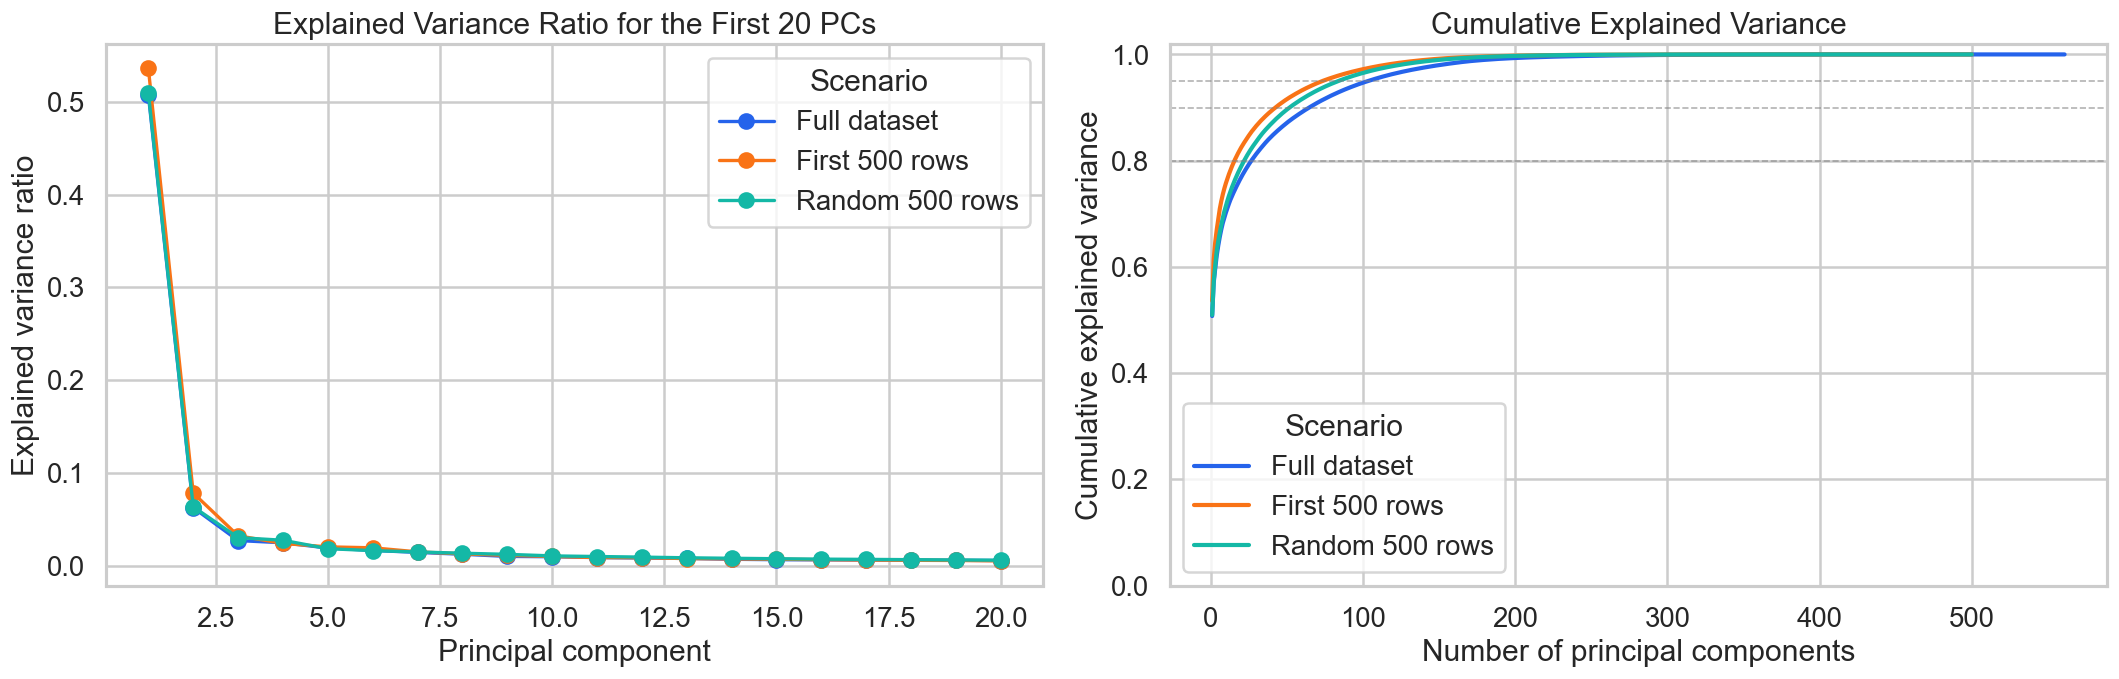

,Scenario,PC1 variance,PC2 variance,PC1 + PC2 cumulative,PCs for 80%,PCs for 90%,PCs for 95%
0,Full dataset (n > p),50.74%,6.24%,56.98%,27,65,104
1,First 500 rows (p > n),53.59%,7.81%,61.41%,16,43,74
2,Random 500 rows (p > n),50.94%,6.34%,57.28%,23,52,84


The first two PCs explain **57.0%** of variance in the full dataset, **61.4%** in the first 500 rows, and **57.3%** in the random 500-row sample. At the 80% / 90% / 95% thresholds, the component counts are **27 / 65 / 104** for the full dataset, **16 / 43 / 74** for the first 500 rows, and **23 / 52 / 84** for the random sample. The first-500 slice compresses variance fastest, but the random 500-row sample sits much closer to the full dataset. That pattern suggests the sharper variance concentration in the first-500 slice is not only a `p > n` effect; narrower coverage is part of the explanation.

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for key in scenario_results_order:
    scenario = scenario_lookup[key]
    result = results[key]
    head = result["explained_variance"].head(20)
    axes[0].plot(
        head["component_number"],
        head["explained_variance_ratio"],
        marker="o",
        linewidth=2,
        color=SCENARIO_COLORS[scenario["short_label"]],
        label=scenario["short_label"],
    )
    axes[1].plot(
        result["explained_variance"]["component_number"],
        result["explained_variance"]["cumulative_explained_variance"],
        linewidth=2.5,
        color=SCENARIO_COLORS[scenario["short_label"]],
        label=scenario["short_label"],
    )

axes[0].set_title("Explained Variance Ratio for the First 20 PCs")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].legend(title="Scenario")
for target in (0.80, 0.90, 0.95):
    axes[1].axhline(target, linestyle="--", linewidth=1, color="gray", alpha=0.6)
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Number of principal components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_ylim(0, 1.02)
axes[1].legend(title="Scenario")
fig.tight_layout()
save_figure(fig, paths["figures"] / "three_way_variance_comparison.png")
plt.show()
plt.close(fig)

variance_display = variance_comparison.copy()
for column in ["PC1_explained_variance_ratio", "PC2_explained_variance_ratio", "first_two_pc_cumulative_variance"]:
    variance_display[column] = (variance_display[column] * 100).round(2).astype(str) + "%"
variance_display = variance_display.rename(
    columns={
        "scenario": "Scenario",
        "PC1_explained_variance_ratio": "PC1 variance",
        "PC2_explained_variance_ratio": "PC2 variance",
        "first_two_pc_cumulative_variance": "PC1 + PC2 cumulative",
        "PCs_for_80_percent": "PCs for 80%",
        "PCs_for_90_percent": "PCs for 90%",
        "PCs_for_95_percent": "PCs for 95%",
    }
)
display(variance_display)

full_pc12 = float(variance_comparison.loc[variance_comparison["scenario"] == "Full dataset (n > p)", "first_two_pc_cumulative_variance"].iloc[0])
first_pc12 = float(variance_comparison.loc[variance_comparison["scenario"] == "First 500 rows (p > n)", "first_two_pc_cumulative_variance"].iloc[0])
random_pc12 = float(variance_comparison.loc[variance_comparison["scenario"] == random_subset_info["title_label"], "first_two_pc_cumulative_variance"].iloc[0])
full_80 = int(variance_comparison.loc[variance_comparison["scenario"] == "Full dataset (n > p)", "PCs_for_80_percent"].iloc[0])
first_80 = int(variance_comparison.loc[variance_comparison["scenario"] == "First 500 rows (p > n)", "PCs_for_80_percent"].iloc[0])
random_80 = int(variance_comparison.loc[variance_comparison["scenario"] == random_subset_info["title_label"], "PCs_for_80_percent"].iloc[0])
full_90 = int(variance_comparison.loc[variance_comparison["scenario"] == "Full dataset (n > p)", "PCs_for_90_percent"].iloc[0])
first_90 = int(variance_comparison.loc[variance_comparison["scenario"] == "First 500 rows (p > n)", "PCs_for_90_percent"].iloc[0])
random_90 = int(variance_comparison.loc[variance_comparison["scenario"] == random_subset_info["title_label"], "PCs_for_90_percent"].iloc[0])
full_95 = int(variance_comparison.loc[variance_comparison["scenario"] == "Full dataset (n > p)", "PCs_for_95_percent"].iloc[0])
first_95 = int(variance_comparison.loc[variance_comparison["scenario"] == "First 500 rows (p > n)", "PCs_for_95_percent"].iloc[0])
random_95 = int(variance_comparison.loc[variance_comparison["scenario"] == random_subset_info["title_label"], "PCs_for_95_percent"].iloc[0])

display(
    Markdown(
        f"The first two PCs explain **{full_pc12:.1%}** of variance in the full dataset, **{first_pc12:.1%}** in the first 500 rows, and **{random_pc12:.1%}** in the random 500-row sample. "
        f"At the 80% / 90% / 95% thresholds, the component counts are **{full_80} / {full_90} / {full_95}** for the full dataset, **{first_80} / {first_90} / {first_95}** for the first 500 rows, and **{random_80} / {random_90} / {random_95}** for the random sample. "
        "The first-500 slice compresses variance fastest, but the random 500-row sample sits much closer to the full dataset. That pattern suggests the sharper variance concentration in the first-500 slice is not only a `p > n` effect; narrower coverage is part of the explanation."
    )
)

## 7. 2D Scatter Plot Comparison Across All Three Settings

The scatter plots are the most presentation-friendly view of the comparison, but they need careful interpretation.

Each PCA fit creates its own coordinate system, so absolute PC values are not directly comparable across panels. The meaningful comparison is the **pattern** of separation, overlap, and clustering: do dynamic activities still separate from mostly stationary ones, and does that story look stable across the two `p > n` choices?

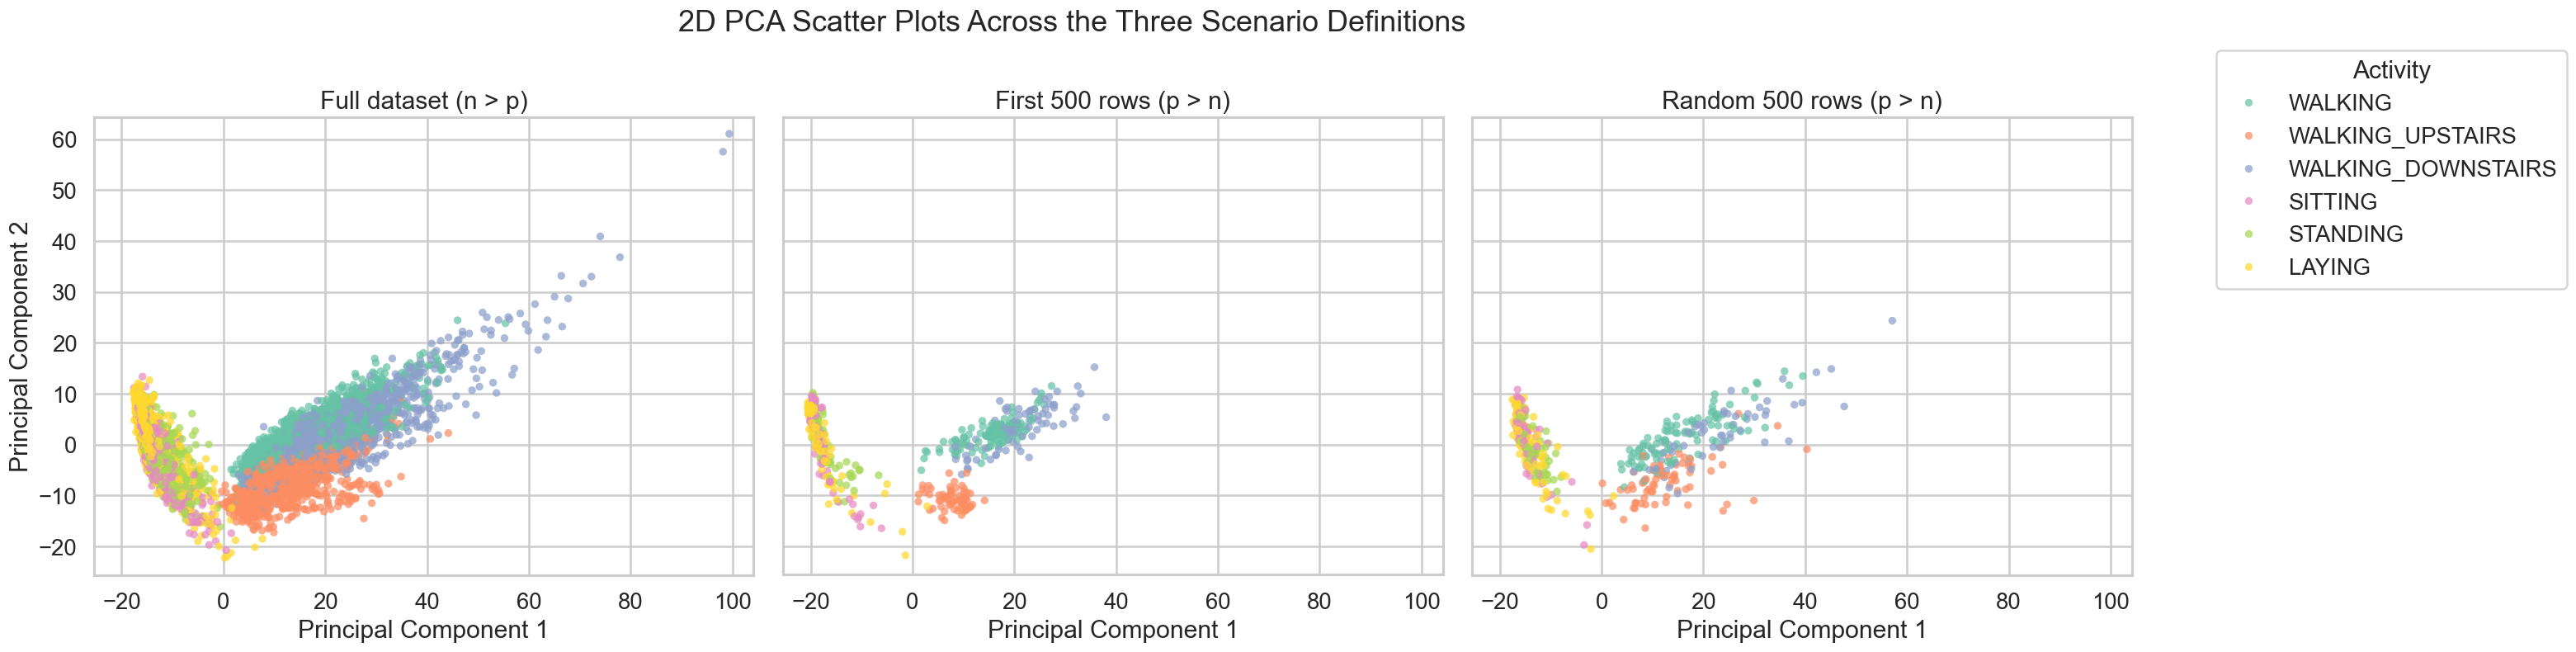

,Scenario,2D silhouette score,Mean centroid distance,Minimum centroid distance,Maximum centroid distance,Average within-class spread
0,Full dataset (n > p),0.0162,21.4042,1.1865,37.8880,6.1191
1,First 500 rows (p > n),0.1090,22.6950,0.7461,38.9896,5.5957
2,Random 500 rows (p > n),-0.0090,21.3735,0.4114,37.4794,6.4460


With shared x- and y-axis limits across all three panels, the **first 500 rows** scenario still shows the strongest 2D separation by the summary metrics: silhouette **0.109** and average within-class spread **5.60**. But the **Random 500 rows** scenario does **not** replicate that stronger pattern; its silhouette is **-0.009** and its average within-class spread is **6.45**, much closer to the full dataset (**0.016**, spread **6.12**). The shared-scale figure makes the visual caution clearer: the first-500-row slice occupies a tighter footprint partly because it is narrower and less diverse, not because PCA automatically works better whenever `p > n`.

In [47]:
all_scores = pd.concat(
    [results[key]["scores_with_labels"][["PC1", "PC2"]] for key in scenario_results_order],
    ignore_index=True,
)
pc1_min, pc1_max = float(all_scores["PC1"].min()), float(all_scores["PC1"].max())
pc2_min, pc2_max = float(all_scores["PC2"].min()), float(all_scores["PC2"].max())
pc1_pad = 0.04 * (pc1_max - pc1_min)
pc2_pad = 0.04 * (pc2_max - pc2_min)

fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharex=True, sharey=True)
legend_handles = None
legend_labels = None
for axis, key in zip(axes, scenario_results_order):
    scenario = scenario_lookup[key]
    result = results[key]
    sns.scatterplot(
        data=result["scores_with_labels"],
        x="PC1",
        y="PC2",
        hue="activity_label",
        hue_order=DEFAULT_ACTIVITY_ORDER,
        palette=ACTIVITY_PALETTE,
        s=32,
        alpha=0.72,
        linewidth=0,
        ax=axis,
    )
    axis.set_title(scenario["title_label"])
    axis.set_xlabel("Principal Component 1")
    axis.set_ylabel("Principal Component 2")
    axis.set_xlim(pc1_min - pc1_pad, pc1_max + pc1_pad)
    axis.set_ylim(pc2_min - pc2_pad, pc2_max + pc2_pad)
    axis.set_aspect("equal", adjustable="box")
    if legend_handles is None:
        legend_handles, legend_labels = axis.get_legend_handles_labels()
    if axis.get_legend() is not None:
        axis.get_legend().remove()

fig.legend(legend_handles, legend_labels, title="Activity", bbox_to_anchor=(1.02, 0.98), loc="upper left")
fig.suptitle("2D PCA Scatter Plots Across the Three Scenario Definitions", y=1.03)
fig.tight_layout()
save_figure(fig, paths["figures"] / "three_way_scatter_comparison.png")
plt.show()
plt.close(fig)

separation_display = separation_comparison.rename(
    columns={
        "scenario": "Scenario",
        "two_pc_silhouette_score": "2D silhouette score",
        "mean_centroid_distance": "Mean centroid distance",
        "min_centroid_distance": "Minimum centroid distance",
        "max_centroid_distance": "Maximum centroid distance",
        "avg_within_class_spread": "Average within-class spread",
    }
).copy()
numeric_columns = separation_display.columns.drop("Scenario")
separation_display[numeric_columns] = separation_display[numeric_columns].round(4)
display(separation_display)

full_silhouette = float(separation_comparison.loc[separation_comparison["scenario"] == "Full dataset (n > p)", "two_pc_silhouette_score"].iloc[0])
first_silhouette = float(separation_comparison.loc[separation_comparison["scenario"] == "First 500 rows (p > n)", "two_pc_silhouette_score"].iloc[0])
random_silhouette = float(separation_comparison.loc[separation_comparison["scenario"] == random_subset_info["title_label"], "two_pc_silhouette_score"].iloc[0])
full_spread = float(separation_comparison.loc[separation_comparison["scenario"] == "Full dataset (n > p)", "avg_within_class_spread"].iloc[0])
first_spread = float(separation_comparison.loc[separation_comparison["scenario"] == "First 500 rows (p > n)", "avg_within_class_spread"].iloc[0])
random_spread = float(separation_comparison.loc[separation_comparison["scenario"] == random_subset_info["title_label"], "avg_within_class_spread"].iloc[0])

display(
    Markdown(
        f"With shared x- and y-axis limits across all three panels, the **first 500 rows** scenario still shows the strongest 2D separation by the summary metrics: silhouette **{first_silhouette:.3f}** and average within-class spread **{first_spread:.2f}**. "
        f"But the **{random_subset_info['short_label']}** scenario does **not** replicate that stronger pattern; its silhouette is **{random_silhouette:.3f}** and its average within-class spread is **{random_spread:.2f}**, much closer to the full dataset (**{full_silhouette:.3f}**, spread **{full_spread:.2f}**). "
        "The shared-scale figure makes the visual caution clearer: the first-500-row slice occupies a tighter footprint partly because it is narrower and less diverse, not because PCA automatically works better whenever `p > n`."
    )
)

## 8. Separation / Clustering Summary Comparison

The table above already summarizes silhouette score, centroid distances, and average within-class spread. Those metrics are useful because they convert the visual impression of the scatter plots into a more explicit comparison.

The scatter plots now use the same x-axis and y-axis limits in all three panels, so differences in spread can be compared directly rather than being influenced by per-panel autoscaling.

The main reading rule is simple:

- higher silhouette scores and larger centroid distances can suggest clearer class separation;
- lower within-class spread can suggest tighter clusters;
- but those gains are not automatically good news if the subset is also much less representative.

In other words, the tighter-looking geometry in the first 500 rows must be interpreted together with the subject-coverage diagnostics from earlier sections.

## 9. PC Interpretation and Loading-Direction Comparison

To stay close to the original notebook, interpretation still focuses on:

- average class centroids in the 2D PCA space;
- grouped loading summaries for PC1 and PC2;
- direct loading-direction alignment across scenarios.

The most informative question here is not whether the coordinates are numerically identical. It is whether the same broad movement story survives across the three fits, and whether the random 500-row sample preserves the full-data directions better than the first-500-row slice.

In [48]:
movement_display = movement_summary.copy().round(2)
movement_display = movement_display.rename(
    columns={
        "scenario": "Scenario",
        "dynamic_mean_pc1": "Mean PC1 for dynamic activities",
        "stationary_mean_pc1": "Mean PC1 for stationary activities",
        "walking_upstairs_mean_pc2": "Mean PC2 for WALKING_UPSTAIRS",
        "other_walking_mean_pc2": "Mean PC2 for WALKING and WALKING_DOWNSTAIRS",
    }
)
display(movement_display)

profile_display = component_profiles[component_profiles["scenario"].isin(["First 500 rows", random_subset_info["short_label"]])].copy()
profile_display = profile_display.rename(
    columns={
        "scenario": "Scenario",
        "component": "Component",
        "top_domain": "Dominant domain",
        "domain_share": "Domain share",
        "top_sensor_family": "Dominant sensor family",
        "sensor_family_share": "Sensor family share",
        "top_feature_style": "Dominant feature style",
        "feature_style_share": "Feature style share",
    }
)
for column in ["Domain share", "Sensor family share", "Feature style share"]:
    profile_display[column] = (profile_display[column] * 100).round(1).astype(str) + "%"

alignment_display = component_alignment.rename(
    columns={
        "comparison": "Comparison",
        "component": "Component",
        "loading_cosine_similarity": "Loading cosine similarity",
        "absolute_cosine_similarity": "Absolute cosine similarity",
        "shared_top_loading_count": "Shared top-15 loading count",
        "shared_feature_examples": "Shared feature examples",
    }
).copy()
alignment_display[["Loading cosine similarity", "Absolute cosine similarity"]] = alignment_display[["Loading cosine similarity", "Absolute cosine similarity"]].round(4)

top_loadings_display = top_loadings[top_loadings["scenario"].isin(["First 500 rows", random_subset_info["short_label"]])].copy()
top_loadings_display["loading"] = top_loadings_display["loading"].round(4)
top_loadings_display["absolute_loading"] = top_loadings_display["absolute_loading"].round(4)
top_loadings_display = top_loadings_display.rename(
    columns={
        "scenario": "Scenario",
        "component": "Component",
        "feature_name": "Feature",
        "loading": "Loading",
        "absolute_loading": "Absolute loading",
    }
)

centroids_display = activity_centroids[activity_centroids["scenario"].isin(["First 500 rows", random_subset_info["short_label"]])].copy()
centroids_display["activity_label"] = pd.Categorical(
    centroids_display["activity_label"],
    categories=DEFAULT_ACTIVITY_ORDER,
    ordered=True,
)
centroids_display = centroids_display.sort_values(["scenario", "activity_label"]).rename(
    columns={
        "scenario": "Scenario",
        "activity_label": "Activity",
        "sample_count": "Rows",
        "mean_pc1": "Mean PC1",
        "mean_pc2": "Mean PC2",
    }
)
centroids_display[["Mean PC1", "Mean PC2"]] = centroids_display[["Mean PC1", "Mean PC2"]].round(2)

display(Markdown("### Simplified component profiles for the two `p > n` scenarios"))
display(profile_display)
display(Markdown("### Pairwise loading-direction alignment across scenarios"))
display(alignment_display)
display(Markdown("### Average class centroids inside the two `p > n` scenarios"))
display(centroids_display)
display(Markdown("### Top loading features for the two `p > n` scenarios"))
display(top_loadings_display)

full_vs_first_pc1 = float(component_alignment.loc[(component_alignment["comparison"] == "Full dataset vs First 500 rows") & (component_alignment["component"] == "PC1"), "absolute_cosine_similarity"].iloc[0])
full_vs_first_pc2 = float(component_alignment.loc[(component_alignment["comparison"] == "Full dataset vs First 500 rows") & (component_alignment["component"] == "PC2"), "absolute_cosine_similarity"].iloc[0])
full_vs_random_pc1 = float(component_alignment.loc[(component_alignment["comparison"] == f"Full dataset vs {random_subset_info['short_label']}") & (component_alignment["component"] == "PC1"), "absolute_cosine_similarity"].iloc[0])
full_vs_random_pc2 = float(component_alignment.loc[(component_alignment["comparison"] == f"Full dataset vs {random_subset_info['short_label']}") & (component_alignment["component"] == "PC2"), "absolute_cosine_similarity"].iloc[0])

display(
    Markdown(
        f"Across all three settings, **PC1 still behaves like a broad movement-versus-posture axis**: the dynamic activities have positive mean PC1 scores while the mostly stationary activities have negative mean PC1 scores in every scenario. "
        f"**PC2 still adds a secondary walking-style split**, with `WALKING_UPSTAIRS` staying distinct from the other walking classes. "
        f"The loading comparison is strongest for the random 500-row sample: absolute cosine similarity is **{full_vs_random_pc1:.3f}** for PC1 and **{full_vs_random_pc2:.3f}** for PC2, compared with **{full_vs_first_pc1:.3f}** and **{full_vs_first_pc2:.3f}** for the first-500-row slice. "
        "That does not prove perfect stability, but it is better evidence that the broad PCA interpretation survives under a more representative `p > n` sample."
    )
)

,Scenario,Mean PC1 for dynamic activities,Mean PC1 for stationary activities,Mean PC2 for WALKING_UPSTAIRS,Mean PC2 for WALKING and WALKING_DOWNSTAIRS
0,Full dataset,17.27,-14.14,-6.72,1.68
1,First 500 rows,15.03,-17.14,-10.63,2.93
2,Random 500 rows,17.22,-14.22,-7.25,1.84


### Simplified component profiles for the two `p > n` scenarios

,Component,Dominant domain,Domain share,Dominant sensor family,Sensor family share,Dominant feature style,Feature style share,Scenario
2,PC1,Frequency domain,52.6%,Body acceleration,70.1%,Magnitude / overall intensity,55.1%,First 500 rows
3,PC2,Time domain,63.6%,Body acceleration,44.4%,Frequency / coefficient pattern,81.6%,First 500 rows
4,PC1,Time domain,52.5%,Body acceleration,75.0%,Magnitude / overall intensity,67.6%,Random 500 rows
5,PC2,Time domain,72.3%,Gravity acceleration,40.2%,Frequency / coefficient pattern,89.3%,Random 500 rows


### Pairwise loading-direction alignment across scenarios

,Comparison,Component,Loading cosine similarity,Absolute cosine similarity,Shared top-15 loading count,Shared feature examples
0,Full dataset vs First 500 rows,PC1,0.9923,0.9923,10,"fBodyAcc-sma(), fBodyAccJerk-sma(), fBodyAccMag-mean(), fBodyAccMag-sma(), fBodyBodyAccJerkMag-mean(), fBodyBodyAccJ..."
1,Full dataset vs First 500 rows,PC2,0.9467,0.9467,12,"fBodyAcc-meanFreq()-Z, fBodyAccMag-meanFreq(), tBodyAccMag-arCoeff()1, tBodyAccMag-arCoeff()2, tBodyGyroMag-arCoeff(..."
2,Full dataset vs Random 500 rows,PC1,0.9990,0.9990,12,"fBodyAcc-sma(), fBodyAccJerk-sma(), fBodyBodyAccJerkMag-mean(), fBodyBodyAccJerkMag-sma(), fBodyGyro-sma(), tBodyAcc..."
3,Full dataset vs Random 500 rows,PC2,0.9853,0.9853,13,"fBodyAcc-meanFreq()-Y, fBodyAcc-meanFreq()-Z, fBodyAccMag-meanFreq(), tBodyAccMag-arCoeff()1, tBodyAccMag-arCoeff()2..."
4,First 500 rows vs Random 500 rows,PC1,0.9921,0.9921,8,"fBodyAcc-sma(), fBodyAccJerk-sma(), fBodyBodyAccJerkMag-mean(), fBodyBodyAccJerkMag-sma(), fBodyGyro-sma(), tBodyAcc..."
5,First 500 rows vs Random 500 rows,PC2,0.9580,0.9580,13,"fBodyAcc-meanFreq()-Z, fBodyAccJerk-meanFreq()-Z, fBodyAccMag-meanFreq(), tBodyAccMag-arCoeff()1, tBodyAccMag-arCoef..."


### Average class centroids inside the two `p > n` scenarios

,Activity,Rows,Mean PC1,Mean PC2,Scenario
9,WALKING,126,16.07,2.30,First 500 rows
11,WALKING_UPSTAIRS,65,7.72,-10.63,First 500 rows
10,WALKING_DOWNSTAIRS,72,21.31,3.56,First 500 rows
7,SITTING,73,-17.56,0.47,First 500 rows
8,STANDING,84,-17.18,1.11,First 500 rows
6,LAYING,80,-16.69,0.22,First 500 rows
15,WALKING,99,16.11,1.59,Random 500 rows
17,WALKING_UPSTAIRS,69,12.90,-7.25,Random 500 rows
16,WALKING_DOWNSTAIRS,61,22.66,2.09,Random 500 rows
13,SITTING,98,-14.82,1.94,Random 500 rows


### Top loading features for the two `p > n` scenarios

,Component,Feature,Loading,Absolute loading,Scenario
20,PC1,fBodyAcc-sma(),0.0574,0.0574,First 500 rows
21,PC1,fBodyAccJerk-sma(),0.0571,0.0571,First 500 rows
22,PC1,fBodyGyro-sma(),0.0570,0.0570,First 500 rows
23,PC1,tBodyAccJerkMag-sma(),0.0570,0.0570,First 500 rows
24,PC1,tBodyAccJerkMag-mean(),0.0570,0.0570,First 500 rows
25,PC1,tBodyAccJerk-sma(),0.0570,0.0570,First 500 rows
26,PC1,fBodyBodyAccJerkMag-mean(),0.0567,0.0567,First 500 rows
27,PC1,fBodyBodyAccJerkMag-sma(),0.0567,0.0567,First 500 rows
28,PC1,fBodyAccMag-sma(),0.0567,0.0567,First 500 rows
29,PC1,fBodyAccMag-mean(),0.0567,0.0567,First 500 rows


Across all three settings, **PC1 still behaves like a broad movement-versus-posture axis**: the dynamic activities have positive mean PC1 scores while the mostly stationary activities have negative mean PC1 scores in every scenario. **PC2 still adds a secondary walking-style split**, with `WALKING_UPSTAIRS` staying distinct from the other walking classes. The loading comparison is strongest for the random 500-row sample: absolute cosine similarity is **0.999** for PC1 and **0.985** for PC2, compared with **0.992** and **0.947** for the first-500-row slice. That does not prove perfect stability, but it is better evidence that the broad PCA interpretation survives under a more representative `p > n` sample.

## 10. What Changed Across the Three Scenarios?

This section ties the diagnostics together before the final takeaway. The point is not to declare a winner, but to separate **robust conclusions** from **sample-selection-sensitive conclusions**.

In [49]:
comparison_text = f'''
### Summary of the three-way comparison

- Moving from the full dataset to either 500-row subset changes the geometry from **`n > p`** to **`p > n`**, so both smaller scenarios are rank-limited after centering and force **62** directions to zero.
- The **first 500 rows** are not just smaller. They are also **order-dependent**, use only **{first_subjects} subjects**, and exclude the test split entirely.
- The **{random_subset_info['short_label']}** scenario is still small, but it covers **{random_subjects} subjects** and includes both train and test rows. It is therefore a much broader check on whether the PCA story survives in a `p > n` regime.
- Variance concentration changes the most in the first-500 slice. The random 500-row sample remains closer to the full dataset on cumulative variance thresholds.
- The first-500 slice also looks cleaner in 2D, but the random 500-row sample does **not** reproduce that gain. That makes the cleaner first-500 scatter plot a **sample-selection-sensitive** finding.
- The broad interpretation of **PC1 = movement intensity / posture contrast** and **PC2 = finer walking-style contrast** is the most robust finding. It appears in all three scenarios and is supported most strongly by the random-sample alignment with the full dataset.
'''
display(Markdown(comparison_text))


### Summary of the three-way comparison

- Moving from the full dataset to either 500-row subset changes the geometry from **`n > p`** to **`p > n`**, so both smaller scenarios are rank-limited after centering and force **62** directions to zero.
- The **first 500 rows** are not just smaller. They are also **order-dependent**, use only **2 subjects**, and exclude the test split entirely.
- The **Random 500 rows** scenario is still small, but it covers **30 subjects** and includes both train and test rows. It is therefore a much broader check on whether the PCA story survives in a `p > n` regime.
- Variance concentration changes the most in the first-500 slice. The random 500-row sample remains closer to the full dataset on cumulative variance thresholds.
- The first-500 slice also looks cleaner in 2D, but the random 500-row sample does **not** reproduce that gain. That makes the cleaner first-500 scatter plot a **sample-selection-sensitive** finding.
- The broad interpretation of **PC1 = movement intensity / posture contrast** and **PC2 = finer walking-style contrast** is the most robust finding. It appears in all three scenarios and is supported most strongly by the random-sample alignment with the full dataset.


## 11. Final Conclusions and Student Takeaways

The last step is to answer the methodological questions directly and carefully, without overclaiming what the experiment proves.

In [50]:
final_takeaways = f'''
1. **What changes when we move from the full dataset to a high-dimensional `p > n` setting?**  
Both 500-row scenarios change the rank structure of the problem: after centering, they can support at most **499** non-zero principal directions, so **62** directions are forced to zero. They also need fewer PCs to reach 80%, 90%, and 95% cumulative variance than the full dataset.

2. **How do the two different `p > n` strategies differ?**  
They share the same `500 x 561` shape, but not the same coverage. The first-500-row slice covers only **{first_subjects} subjects** and only the training split, while the {random_subset_info['short_label'].lower()} covers **{random_subjects} subjects** and includes both train and test rows.

3. **Why is the “first 500 rows” case methodologically weaker than the random 500-row case?**  
Because it is driven by row order rather than representativeness. In this dataset, the top two subjects account for **{first_top_two:.1%}** of the first-500 slice, compared with only **{random_top_two:.1%}** in the random sample. That makes the first-500 slice much narrower and more sensitive to who appears early in the merged table.

4. **Does PCA still give a useful 2D summary in both `p > n` settings?**  
Yes, but with different confidence levels. Both `p > n` subsets still show the broad dynamic-versus-stationary separation along PC1, and `WALKING_UPSTAIRS` remains distinct along PC2. The random sample shows that this interpretation survives beyond the narrow first-500 slice.

5. **Which conclusions are robust across all three scenarios, and which are sensitive to how the 500 rows were chosen?**  
Robust: the main movement/posture contrast remains visible, and the leading loading directions stay very similar across fits. Sensitive: the tighter shared-scale scatter and stronger variance concentration in the first-500 slice are **not** reproduced by the random 500-row sample, so they should not be treated as generic properties of `p > n`.

6. **What should a student learn from this experiment about dimensionality, representativeness, and interpretation?**  
High dimensionality is about the relationship between `p` and `n`, not just having many columns. PCA can still be useful when `p > n`, but interpretation depends on who is in the sample. A narrow convenience subset can make PCA look tighter than it really is under a fair shared scale, so dimensionality arguments should always be checked against representativeness and coverage.
'''
display(Markdown(final_takeaways))


1. **What changes when we move from the full dataset to a high-dimensional `p > n` setting?**  
Both 500-row scenarios change the rank structure of the problem: after centering, they can support at most **499** non-zero principal directions, so **62** directions are forced to zero. They also need fewer PCs to reach 80%, 90%, and 95% cumulative variance than the full dataset.

2. **How do the two different `p > n` strategies differ?**  
They share the same `500 x 561` shape, but not the same coverage. The first-500-row slice covers only **2 subjects** and only the training split, while the random 500 rows covers **30 subjects** and includes both train and test rows.

3. **Why is the “first 500 rows” case methodologically weaker than the random 500-row case?**  
Because it is driven by row order rather than representativeness. In this dataset, the top two subjects account for **100.0%** of the first-500 slice, compared with only **11.0%** in the random sample. That makes the first-500 slice much narrower and more sensitive to who appears early in the merged table.

4. **Does PCA still give a useful 2D summary in both `p > n` settings?**  
Yes, but with different confidence levels. Both `p > n` subsets still show the broad dynamic-versus-stationary separation along PC1, and `WALKING_UPSTAIRS` remains distinct along PC2. The random sample shows that this interpretation survives beyond the narrow first-500 slice.

5. **Which conclusions are robust across all three scenarios, and which are sensitive to how the 500 rows were chosen?**  
Robust: the main movement/posture contrast remains visible, and the leading loading directions stay very similar across fits. Sensitive: the tighter shared-scale scatter and stronger variance concentration in the first-500 slice are **not** reproduced by the random 500-row sample, so they should not be treated as generic properties of `p > n`.

6. **What should a student learn from this experiment about dimensionality, representativeness, and interpretation?**  
High dimensionality is about the relationship between `p` and `n`, not just having many columns. PCA can still be useful when `p > n`, but interpretation depends on who is in the sample. A narrow convenience subset can make PCA look tighter than it really is under a fair shared scale, so dimensionality arguments should always be checked against representativeness and coverage.


## Saved Outputs

This notebook saves the revised three-way comparison artifacts to the existing project output folders.

**Figures**
- `outputs/figures/three_way_class_count_comparison.png`
- `outputs/figures/three_way_subject_coverage.png`
- `outputs/figures/three_way_variance_comparison.png`
- `outputs/figures/three_way_scatter_comparison.png`

**Tables**
- `outputs/tables/three_way_overview.csv`
- `outputs/tables/three_way_setting_comparison.csv`
- `outputs/tables/three_way_dataset_checks.csv`
- `outputs/tables/three_way_class_count_comparison.csv`
- `outputs/tables/three_way_subject_coverage.csv`
- `outputs/tables/three_way_subject_concentration.csv`
- `outputs/tables/three_way_scaling_checks.csv`
- `outputs/tables/three_way_raw_vs_standardized_examples.csv`
- `outputs/tables/three_way_variance_comparison.csv`
- `outputs/tables/three_way_separation_comparison.csv`
- `outputs/tables/three_way_component_alignment.csv`
- `outputs/tables/three_way_dimension_comparison.csv`
- `outputs/tables/three_way_activity_centroids.csv`
- `outputs/tables/three_way_component_profiles.csv`
- `outputs/tables/three_way_first_500_component_profile.csv`
- `outputs/tables/three_way_random_500_component_profile.csv`
- `outputs/tables/three_way_top_pc_loadings.csv`